In [1]:
import torch

import matplotlib.pyplot as plt

from utils.config import *
from utils.components import *
from utils.masking import BinaryMasking
from utils.einmask import EinMask
from utils.loss_fn import f_kernel_crps

In [ ]:
torch.nn.ModuleDict({
            'time': BinaryMasking(world, event_cfg={"t": 0.1}, rate_cfg={'min': 1/3, 'max': 2/3}),
            'space': BinaryMasking(world, event_cfg={"h": 0.5, "w": 0.5}, rate_cfg={'min': 1/3, 'max': 2/3}),
            'variable': BinaryMasking(world, event_cfg={"v": 0.1}, rate_cfg={'min': 1/3, 'max': 2/3}),
            'mixed': BinaryMasking(world, event_cfg={"t": 0.5, "v": 0.5}, rate_cfg={'min': 1/3, 'max': 2/3}),
            })

In [ ]:
{"v": 1., "t": 0.31, "h": 3.1, "w": 3.1}

In [15]:
class Objective(torch.nn.Module):
    def __init__(self, world: WorldConfig, network: NetworkConfig) -> None:
        super().__init__()
        self.world = world
        self.model = EinMask(network, world)

        self.tasks = torch.nn.ModuleDict({
            'time': BinaryMasking(world, event_cfg={}, rate_cfg={'min': 1/3, 'max': 2/3}),
            'space': BinaryMasking(world, event_cfg={}, rate_cfg={'min': 1/3, 'max': 2/3}),
            'variable': BinaryMasking(world, event_cfg={}, rate_cfg={'min': 1/3, 'max': 2/3}),
            'mixed': BinaryMasking(world, event_cfg={}, rate_cfg={'min': 1/3, 'max': 2/3}),
            })
        
    def forward(self, obs: torch.Tensor, rng: torch.Generator = None):
        B = obs.size(0)
        K = len(self.tasks)
        
        # sample src masks and tgt masks for all tasks
        src_masks, tgt_masks = [], []
        for prior in self.tasks.values():
            src = prior(B, rng)
            tgt = prior(B, conditional=src, rng=rng)
            src_masks.append(src)
            tgt_masks.append(tgt)
        
        # concatenate into single batch
        all_src = torch.cat(src_masks, dim=0)        # (K*B, N)
        all_obs = einops.repeat(obs, 'b ... -> (k b) ...', k=K)
        
        # single forward pass
        prediction = self.model(all_obs, all_src, members=4, rng=rng)
        loss = f_kernel_crps(all_obs, prediction, fair=True)
        
        # K backward passes over task slices
        grads = {}
        for i, key in enumerate(self.tasks.keys()):
            tgt = einops.repeat(tgt_masks[i], f'b ({self.world.token_pattern}) -> b {self.world.field_pattern}', 
                            **self.world.token_sizes, **self.world.patch_sizes)
            self.model.zero_grad()
            task_loss = loss[i*B:(i+1)*B][tgt].mean()
            task_loss.backward(retain_graph=i < K-1)
            grads[key] = [p.grad.clone() for p in self.model.parameters() if p.requires_grad]
        
        return grads

In [16]:
network = NetworkConfig(dim_noise=16, dim_in=256, dim_out=128, num_read_blocks=4, num_write_blocks=2, num_latents=64)
world = WorldConfig({'v': 9, "t": 36, 'h': 64, 'w':120}, patch_sizes={'vv':1, 'tt': 6, 'ww':8, 'hh':8}, batch_size=2)


objective = Objective(world, network)
print(f'params: {count_parameters(objective.model):,}')


params: 8,237,712


In [17]:
test = objective(torch.randn((2, *world.field_shape)))

In [18]:
def task_confusion(grads: Dict[str, List[torch.Tensor]]) -> Dict[Tuple[str, str], float]:
    keys = list(grads.keys())
    confusion = {}
    for ki in keys:
        for kj in keys:
            if ki == kj:
                continue
            cos = sum(
                torch.nn.functional.cosine_similarity(gi.flatten(), gj.flatten(), dim=0)
                for gi, gj in zip(grads[ki], grads[kj])
            ) / len(grads[ki])
            confusion[(ki, kj)] = cos.item()
    return confusion

In [19]:
confusion = task_confusion(test)

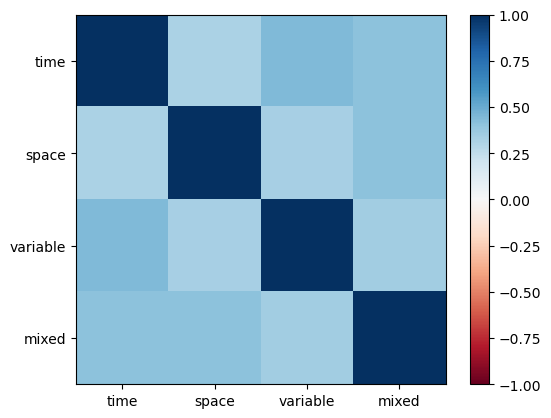

In [20]:
keys = list(test.keys())

matrix = torch.zeros((len(keys), len(keys)))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        matrix[i, j] = confusion.get((ki, kj), 1.0)  # diagonal = 1

fig, ax = plt.subplots()
im = ax.imshow(matrix, vmin=-1, vmax=1, cmap='RdBu')
ax.set_xticks(range(len(keys))); ax.set_xticklabels(keys)
ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys)
plt.colorbar(im)